In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from wordcloud import WordCloud

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# For Word2Vec
import gensim.downloader as api

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Nitro\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Nitro\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Nitro\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [5]:
df = pd.read_csv(r'C:\Users\Nitro\Desktop\ai-deeplearning\2. Hotel Review Dataset\Hotel_Reviews.csv')
print(f"Dataset loaded: {df.shape[0]} reviews")

# Rating distribution 
print("\nRating Distribution:")
rating_dist = df['Rating'].value_counts().sort_index()
for rating, count in rating_dist.items():
    percentage = (count / len(df)) * 100
    print(f"  {rating} stars: {count} reviews ({percentage:.1f}%)")

print(df.info())




Dataset loaded: 20491 reviews

Rating Distribution:
  1 stars: 1421 reviews (6.9%)
  2 stars: 1793 reviews (8.8%)
  3 stars: 2184 reviews (10.7%)
  4 stars: 6039 reviews (29.5%)
  5 stars: 9054 reviews (44.2%)
<class 'pandas.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Review  20491 non-null  str  
 1   Rating  20491 non-null  int64
dtypes: int64(1), str(1)
memory usage: 320.3 KB
None


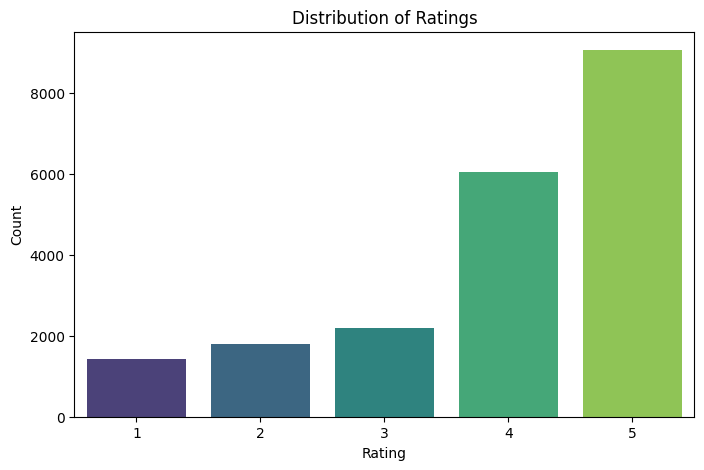

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Rating', data=df, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks()
plt.show()


In [7]:
import contractions 

stop_words = set(stopwords.words('english'))

words_to_keep = {'not','no', 'nor', 'neither', 'never', 'none'}
lemmatizer = WordNetLemmatizer()
stop_words = stop_words - words_to_keep
# Dictionary for Contractions
# contractions_dict = {
#     "don't": "do not", "can't": "cannot", "it's": "it is", "isn't": "is not",
#     "won't": "will not", "I'm": "I am", "you're": "you are", "he's": "he is",
#     "she's": "she is", "we're": "we are", "they're": "they are"
# }

def clean_text(text):
    text = text.lower()
    text = contractions.fix(text)

    # Removing URLS, Special Characters
    text = re.sub(r'https\S+|www\S+|http\S+', '', text, flags=re.MULTILINE) #S+ : Until you hit space grab the character
    text = re.sub(r'@\w+|#\w+', '', text) # Letters and number, after @ #
    text = re.sub(r'\d+', '', text) # \d : Remove numbers digits only
    text = re.sub(r'[^\w\s]', '', text) # ^ means NOT, find everything that is not a number,letter space (!, , , .)

    #Tokenize, Remove stopwords, lemmatize
    tokens = text.split()
    cleaned_tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(cleaned_tokens)

print("Cleaning Text")
df['Cleaned_Review'] = df['Review'].apply(clean_text)
display(df[['Review', 'Cleaned_Review']].head())
        

Cleaning Text


,Review,Cleaned_Review
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice room not experience hotel monaco seattle ...
3,"unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...


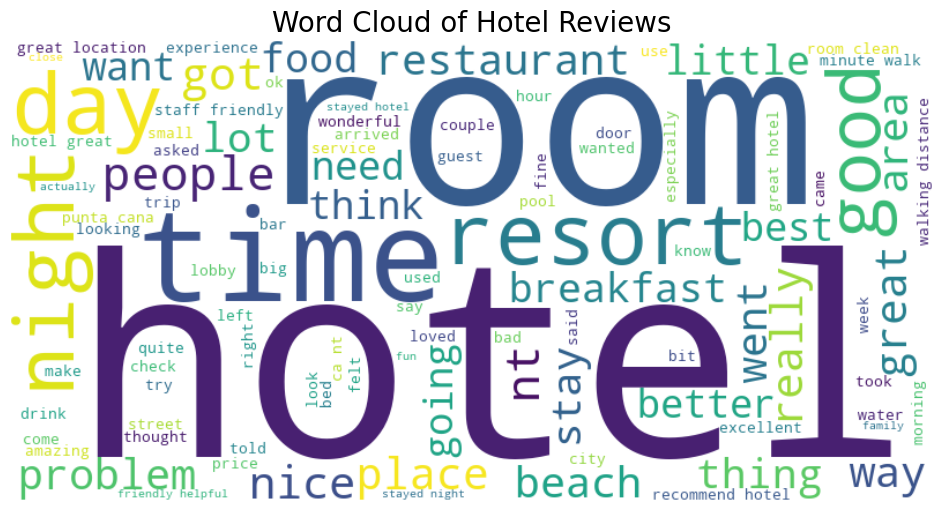

In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# Combining all cleaned reviews into one string
all_text =  " ".join(review for review in df.Cleaned_Review)

#Generate the word cloud
wordcloud = WordCloud(width=800, height =400,
                     background_color = 'white',
                     max_words = 100,
                     colormap = 'viridis').generate(all_text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Hotel Reviews', fontsize=20)
plt.show()

In [9]:
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Prepare data - ensure proper encoding
X = df['Cleaned_Review'].values
y_raw = df['Rating'].values - 1  # Convert 1-5 to 0-4

# Verify all 5 classes exist
print(f"Unique classes in y_raw: {np.unique(y_raw)}")  # Should show [0 1 2 3 4]
print(f"Class distribution: {np.bincount(y_raw)}")

# One-hot encode properly
y = to_categorical(y_raw, num_classes=5)

# Split BOTH one-hot (y) and integer (y_raw) labels so we have both available
X_train, X_test, y_train, y_test, y_train_int, y_test_int = train_test_split(
    X, y, y_raw, test_size=0.2, random_state=42,
    stratify=y_raw  # Stratify by original integer labels
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"y_train shape: {y_train.shape}")        # One-hot: (N, 5)
print(f"y_train_int shape: {y_train_int.shape}")  # Integer: (N,)

Unique classes in y_raw: [0 1 2 3 4]
Class distribution: [1421 1793 2184 6039 9054]
Training samples: 16392
Testing samples: 4099
y_train shape: (16392, 5)
y_train_int shape: (16392,)


In [10]:

# Your rating distribution
rating_counts = {1: 1421, 2: 1793, 3: 2184, 4: 6039, 5: 9054}
total = sum(rating_counts.values())  # 20491
from sklearn.utils import class_weight
import numpy as np

# y_train_int already contains integer labels (0-4) from the split above.
# Do NOT do y_train - 1 here; y_train is one-hot (shape N x 5), not integers.

# Calculate class weights automatically
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)

# Convert to dictionary format that Keras expects
class_weight_dict = dict(enumerate(class_weights))

print("Class Weights for Training:")
for class_idx, weight in enumerate(class_weights):
    print(f"  Rating {class_idx+1} (class {class_idx}): {weight:.4f}")


Class Weights for Training:
  Rating 1 (class 0): 2.8834
  Rating 2 (class 1): 2.2862
  Rating 3 (class 2): 1.8766
  Rating 4 (class 3): 0.6786
  Rating 5 (class 4): 0.4526


In [11]:
# oov_token ensures unknown words in test set get a special token (index 1)
# instead of being silently dropped, which was shortening test sequences
VOCAB_SIZE = 20000
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<oov>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

vocab_size = VOCAB_SIZE
print(f"Vocabulary size: {vocab_size}")


Vocabulary size: 20000


In [12]:
from sklearn.model_selection import train_test_split as tts

lengths = [len(seq) for seq in X_train_seq]
# FIX 3: Use 98th percentile so fewer long reviews get truncated
# Long reviews carry the most nuanced sentiment signal
max_len = int(np.percentile(lengths, 98))
print(f"Max sequence length (95th pct): {max_len}")

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding="post", truncating="post")

# Split off a proper validation set from training data (like friend's notebook)
X_tr, X_val_pad, y_tr_int, y_val_int = tts(
    X_train_pad, y_train_int, test_size=0.1, random_state=42, stratify=y_train_int
)
y_tr_onehot  = y_train[np.isin(X_train_pad, X_tr).all(axis=1)]  # keep alignment

# Simpler: just re-split cleanly using indices
idx = np.arange(len(X_train_pad))
tr_idx, val_idx = tts(idx, test_size=0.1, random_state=42, stratify=y_train_int)

X_tr      = X_train_pad[tr_idx];  X_val_pad = X_train_pad[val_idx]
y_tr_int  = y_train_int[tr_idx];  y_val_int = y_train_int[val_idx]
y_tr_oh   = y_train[tr_idx];      y_val_oh  = y_train[val_idx]

print(f"Train: {X_tr.shape}, Val: {X_val_pad.shape}, Test: {X_test_pad.shape}")


Max sequence length (95th pct): 379
Train: (14752, 379), Val: (1640, 379), Test: (4099, 379)


In [13]:

# y_train_int is already available as integer labels (0-4) from the split cell.
# No need to derive it from y_train_encoded (which no longer exists).
print(f"y_train_int shape: {y_train_int.shape}")   # Should be 1-D
print(f"Unique classes: {np.unique(y_train_int)}")  # Should show [0 1 2 3 4]

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weight_dict = {i: class_weights[i] for i in range(5)}
print(f"Class weights: {class_weight_dict}")

y_train_int shape: (16392,)
Unique classes: [0 1 2 3 4]
Class weights: {0: np.float64(2.883377308707124), 1: np.float64(2.2861924686192467), 2: np.float64(1.876588437321122), 3: np.float64(0.6786172635065204), 4: np.float64(0.45263012563854754)}


In [14]:
# y_train is already one-hot encoded (shape N x 5) from the split above.
# Aliasing it as y_train_onehot so downstream cells work without changes.
y_train_onehot = y_train
y_test_onehot  = y_test

print(f"y_train_onehot shape: {y_train_onehot.shape}")   # Should be (N, 5)
print(f"y_train_onehot sample: {y_train_onehot[0]}")     # Should show one-hot vector
print(f"Unique integer classes: {np.unique(y_train_int)}")  # Should show [0 1 2 3 4]

y_train_onehot shape: (16392, 5)
y_train_onehot sample: [0. 0. 0. 0. 1.]
Unique integer classes: [0 1 2 3 4]


In [15]:
# FIX 1: Replace SimpleRNN with BidirectionalRNN to avoid vanishing gradient
# SimpleRNN loses context over long sequences; Bidirectional processes both directions

from tensorflow.keras.layers import Bidirectional

def build_rnn_model():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
        Bidirectional(SimpleRNN(128, return_sequences=True, dropout=0.3)),
        Bidirectional(SimpleRNN(64, dropout=0.3)),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(5, activation="softmax")
    ])
    return model

model_rnn = build_rnn_model()
model_rnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_rnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## RNN

In [17]:
import time

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stop_rnn = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_rnn = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint_rnn = ModelCheckpoint(
    "best_rnn_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Start timer
start_time = time.time()

print("Training Simple RNN...")

history_rnn = model_rnn.fit(
    X_tr,
    y_tr_int,
    validation_data=(X_val_pad, y_val_int),
    epochs=25,
    batch_size=32,
    callbacks=[
        early_stop_rnn,
        reduce_lr_rnn,
        checkpoint_rnn
    ],
    class_weight=class_weight_dict,
    verbose=1
)

# End timer
end_time = time.time()

training_time = end_time - start_time

print(f"\nTotal Training Time: {training_time:.2f} seconds")
print(f"Total Training Time: {training_time/60:.2f} minutes")

Training Simple RNN...
Epoch 1/25
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.1839 - loss: 1.6583
Epoch 1: val_loss improved from None to 1.46121, saving model to best_rnn_model.keras

Epoch 1: finished saving model to best_rnn_model.keras
461/461 ━━━━━━━━━━━━━━━━━━━━ 104s 226ms/step - accuracy: 0.2132 - loss: 1.6139 - val_accuracy: 0.2787 - val_loss: 1.4612 - learning_rate: 0.0010
Epoch 2/25
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.3877 - loss: 1.3756
Epoch 2: val_loss improved from 1.46121 to 1.18871, saving model to best_rnn_model.keras

Epoch 2: finished saving model to best_rnn_model.keras
461/461 ━━━━━━━━━━━━━━━━━━━━ 107s 233ms/step - accuracy: 0.4222 - loss: 1.3190 - val_accuracy: 0.4646 - val_loss: 1.1887 - learning_rate: 0.0010
Epoch 3/25
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.4932 - loss: 1.1699
Epoch 3: val_loss improved from 1.18871 to 1.04492, saving model to best_rnn_model.keras

Epoch 3: finished saving model to best_rnn_mod

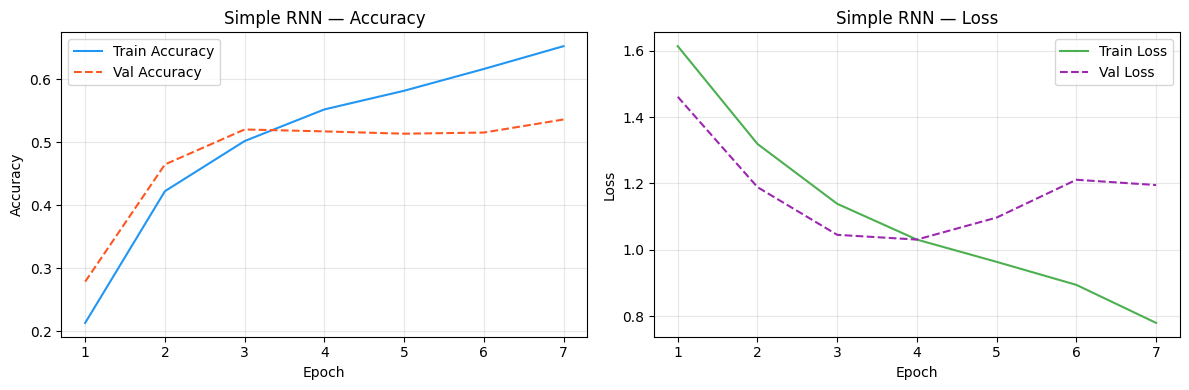

In [18]:
epochs = range(1, len(history_rnn.history["accuracy"]) + 1)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_rnn.history["accuracy"], color="#2196F3", label="Train Accuracy")
plt.plot(epochs, history_rnn.history["val_accuracy"], color="#FF5722", linestyle="--", label="Val Accuracy")
plt.title("Simple RNN — Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, history_rnn.history["loss"], color="#4CAF50", label="Train Loss")
plt.plot(epochs, history_rnn.history["val_loss"], color="#9C27B0", linestyle="--", label="Val Loss")
plt.title("Simple RNN — Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## LSTM

In [20]:
from tensorflow.keras.layers import Bidirectional
import time

def build_lstm_model():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
        Bidirectional(LSTM(128, dropout=0.3, recurrent_dropout=0.2)),
        Dense(64, activation="relu"),
        Dropout(0.5),
        Dense(5, activation="softmax")
    ])
    return model

model_lstm = build_lstm_model()
model_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_lstm.summary()

early_stop_lstm = EarlyStopping(
    monitor="val_loss", patience=4, restore_best_weights=True, verbose=1
)
reduce_lr_lstm = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1
)

checkpoint_lstm = ModelCheckpoint(
    "best_lstm_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

print("Training Bidirectional LSTM...")

start_time = time.time()

history_lstm = model_lstm.fit(
    X_tr,y_tr_int,validation_data=(X_val_pad, y_val_int),epochs=25,batch_size=64,
    callbacks=[
        early_stop_lstm,
        reduce_lr_lstm,
        checkpoint_lstm
    ],
    class_weight=class_weight_dict,
    verbose=1
)

elapsed = time.time() - start_time

print(f"\nTraining completed in {int(elapsed // 60)}m {int(elapsed % 60)}s")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Training Bidirectional LSTM...
Epoch 1/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3644 - loss: 1.4385
Epoch 1: val_loss improved from None to 0.89818, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 735s 3s/step - accuracy: 0.4672 - loss: 1.2684 - val_accuracy: 0.5963 - val_loss: 0.8982 - learning_rate: 0.0010
Epoch 2/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6020 - loss: 1.0015
Epoch 2: val_loss did not improve from 0.89818
231/231 ━━━━━━━━━━━━━━━━━━━━ 751s 3s/step - accuracy: 0.6116 - loss: 0.9603 - val_accuracy: 0.6055 - val_loss: 0.9306 - learning_rate: 0.0010
Epoch 3/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6552 - loss: 0.8565
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_loss did not improve from 0.89818
231/231 ━━━━━━━━━━━━━━━━━━━━ 766s 3s/step - accuracy: 0.6588 - loss: 0.8225 - val_accuracy: 0.6049 - val_loss: 0.92

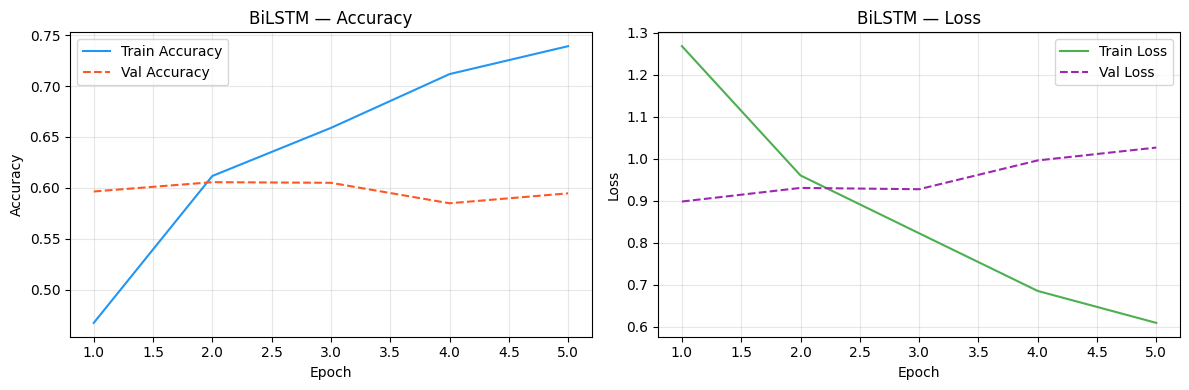

In [21]:
epochs = range(1, len(history_lstm.history["accuracy"]) + 1)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_lstm.history["accuracy"], color="#2196F3", label="Train Accuracy")
plt.plot(epochs, history_lstm.history["val_accuracy"], color="#FF5722", linestyle="--", label="Val Accuracy")
plt.title("BiLSTM — Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, history_lstm.history["loss"], color="#4CAF50", label="Train Loss")
plt.plot(epochs, history_lstm.history["val_loss"], color="#9C27B0", linestyle="--", label="Val Loss")
plt.title("BiLSTM — Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
import gensim.downloader as api

print("Loading GloVe embeddings")
word2vec = api.load("glove-wiki-gigaword-100")

embedding_dim = 100
embedding_matrix = np.zeros((vocab_size, embedding_dim))

hit, miss = 0, 0
for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        if word in word2vec:
            embedding_matrix[i] = word2vec[word]
            hit += 1
        else:
            miss += 1

print(f"Embedding hits: {hit}, misses: {miss}")


Loading GloVe embeddings
Embedding hits: 15583, misses: 4416


In [23]:
# FIX 2: Unfreeze GloVe embeddings (trainable=True) so the model can adapt
# hotel-domain vocabulary (concierge, amenities, checkout, etc.)

def build_lstm_pretrained_model():
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            input_length=max_len,
            trainable=True   # Fine-tune GloVe on hotel reviews
        ),
        Bidirectional(LSTM(128, dropout=0.3, recurrent_dropout=0.2)),
        Dense(64, activation="relu"),
        Dropout(0.5),
        Dense(5, activation="softmax")
    ])
    return model

model_pretrained = build_lstm_pretrained_model()


In [24]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

import time

model_pretrained.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_pretrained.summary()

early_stop_pre = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_pre = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint_pre = ModelCheckpoint(
    "best_glove_lstm_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

print("Training LSTM with GloVe embeddings...")

start_time = time.time()

history_pretrained = model_pretrained.fit(
    X_tr,
    y_tr_int,
    validation_data=(X_val_pad, y_val_int),
    epochs=25,
    batch_size=64,
    callbacks=[
        early_stop_pre,
        reduce_lr_pre,
        checkpoint_pre
    ],
    class_weight=class_weight_dict,
    verbose=1
)

elapsed = time.time() - start_time

print(f"\nTraining completed in {int(elapsed // 60)}m {int(elapsed % 60)}s")


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Training LSTM with GloVe embeddings...
Epoch 1/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3580 - loss: 1.4593
Epoch 1: val_loss improved from None to 0.94887, saving model to best_glove_lstm_model.keras

Epoch 1: finished saving model to best_glove_lstm_model.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 713s 3s/step - accuracy: 0.4171 - loss: 1.3318 - val_accuracy: 0.5750 - val_loss: 0.9489 - learning_rate: 0.0010
Epoch 2/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5268 - loss: 1.1213
Epoch 2: val_loss improved from 0.94887 to 0.89045, saving model to best_glove_lstm_model.keras

Epoch 2: finished saving model to best_glove_lstm_model.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 722s 3s/step - accuracy: 0.5389 - loss: 1.0846 - val_accuracy: 0.6098 - val_loss: 0.8905 - learning_rate: 0.0010
Epoch 3/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5899 - loss: 0.9945
Epoch 3: val_loss improved from 0.89045 to 0.86821, saving model to best_glove_lstm_model.keras

Epoch 3: f

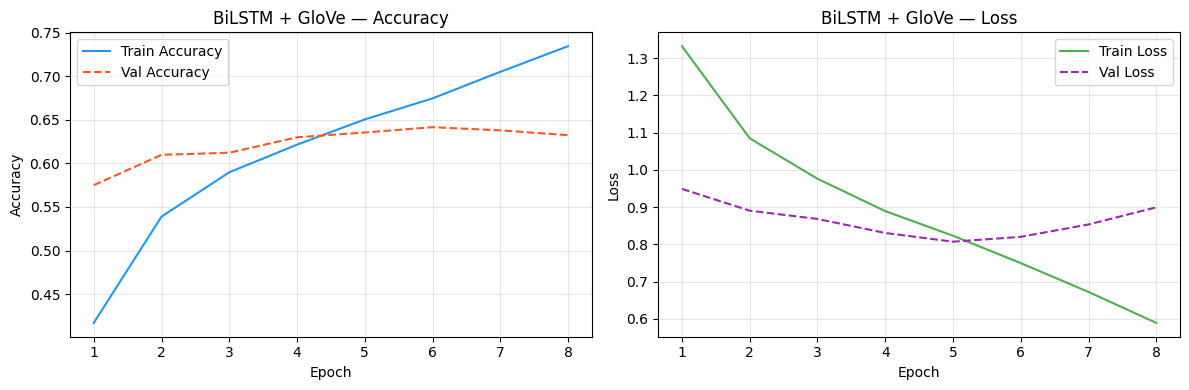

In [25]:
epochs = range(1, len(history_pretrained.history["accuracy"]) + 1)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_pretrained.history["accuracy"], color="#2196F3", label="Train Accuracy")
plt.plot(epochs, history_pretrained.history["val_accuracy"], color="#FF5722", linestyle="--", label="Val Accuracy")
plt.title("BiLSTM + GloVe — Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, history_pretrained.history["loss"], color="#4CAF50", label="Train Loss")
plt.plot(epochs, history_pretrained.history["val_loss"], color="#9C27B0", linestyle="--", label="Val Loss")
plt.title("BiLSTM + GloVe — Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluation and Comparison

In [27]:

print("Model Evaluation and Comparison")


models_list = [
    (model_rnn,        history_rnn,        "Simple RNN"),
    (model_lstm,       history_lstm,       "BiLSTM"),
    (model_pretrained, history_pretrained, "BiLSTM + GloVe"),
]

results = []
for model, history, name in models_list:
    test_loss, test_acc = model.evaluate(X_test_pad, y_test_int, verbose=0)
    pred_probs   = model.predict(X_test_pad, verbose=0)
    pred_classes = np.argmax(pred_probs, axis=1)
    results.append({"name": name, "accuracy": test_acc, "loss": test_loss,
                    "predictions": pred_classes, "true": y_test_int, "history": history})
    print(f"\n{name}: Accuracy={test_acc:.4f}  Loss={test_loss:.4f}")

best = max(results, key=lambda x: x["accuracy"])
print(f"\n Best Model: {best['name']} — {best['accuracy']:.4f}")


Model Evaluation and Comparison

Simple RNN: Accuracy=0.5272  Loss=1.0492

BiLSTM: Accuracy=0.5823  Loss=0.9327

BiLSTM + GloVe: Accuracy=0.6070  Loss=0.8714

 Best Model: BiLSTM + GloVe — 0.6070


In [28]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

print(f"\n{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1 Score':>10}")
print("─" * 65)
for r in results:
    acc  = accuracy_score (r["true"], r["predictions"])
    prec = precision_score(r["true"], r["predictions"], average="weighted", zero_division=0)
    rec  = recall_score   (r["true"], r["predictions"], average="weighted", zero_division=0)
    f1   = f1_score       (r["true"], r["predictions"], average="weighted", zero_division=0)
    print(f"{r['name']:<25} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")


Model                       Accuracy  Precision     Recall   F1 Score
─────────────────────────────────────────────────────────────────
Simple RNN                    0.5272     0.5599     0.5272     0.5370
BiLSTM                        0.5823     0.5975     0.5823     0.5798
BiLSTM + GloVe                0.6070     0.6358     0.6070     0.6151


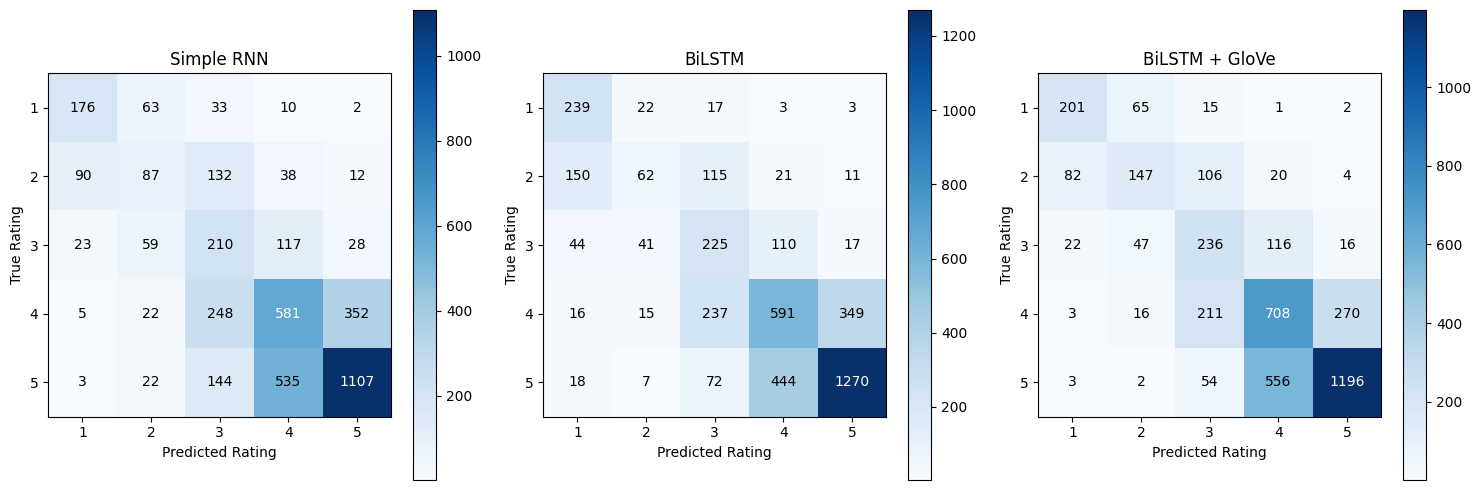

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, r in enumerate(results):
    cm = confusion_matrix(r['true'], r['predictions'])
    
    im = axes[i].imshow(cm, interpolation='nearest', cmap='Blues')
    axes[i].set_title(f'{r["name"]}')
    axes[i].set_xlabel('Predicted Rating')
    axes[i].set_ylabel('True Rating')
    axes[i].set_xticks(range(5))
    axes[i].set_yticks(range(5))
    axes[i].set_xticklabels([1,2,3,4,5])
    axes[i].set_yticklabels([1,2,3,4,5])
    
    # Add numbers
    for row in range(5):
        for col in range(5):
            axes[i].text(col, row, str(cm[row, col]), 
                        ha='center', va='center',
                        color='white' if cm[row, col] > cm.max()/2 else 'black')
    
    plt.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.savefig('confusion_matrices_with_weights.png', dpi=100)
plt.show()

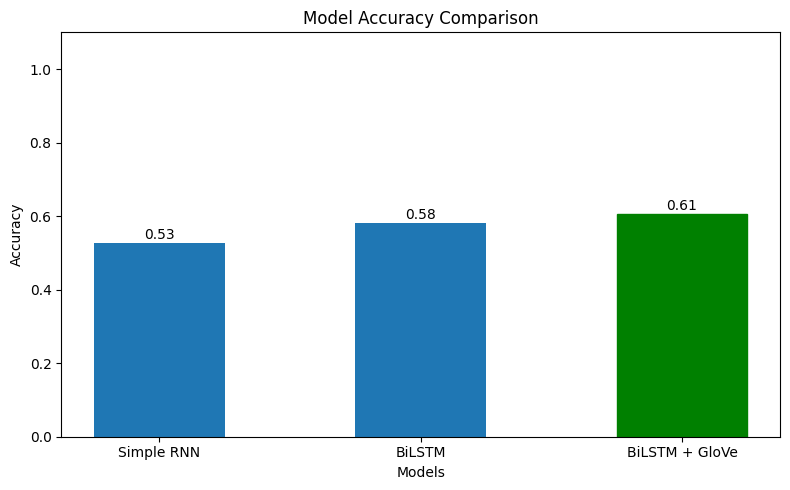

In [32]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Model names and accuracies
names = [r['name'] for r in results]
accuracies = [accuracy_score(r['true'], r['predictions']) for r in results]

# Create bar plot
plt.figure(figsize=(8,5))

bars = plt.bar(names, accuracies, width=0.5)

# Add accuracy values on top of bars
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{acc:.2f}",
        ha='center'
    )

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)

# Highlight best model
best_index = accuracies.index(max(accuracies))
bars[best_index].set_color('green')

plt.tight_layout()
plt.show()

In [33]:
import gradio as gr
import numpy as np

def preprocess_for_prediction(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    return padded

def predict_rating(text, model_choice):
    processed = preprocess_for_prediction(text)
    
    if model_choice == "Simple RNN":
        pred_probs = model_rnn.predict(processed, verbose=0)
    elif model_choice == "LSTM":
        pred_probs = model_lstm.predict(processed, verbose=0)
    else:
        pred_probs = model_pretrained.predict(processed, verbose=0)
    
    predicted_class = np.argmax(pred_probs[0])
    rating = predicted_class + 1
    confidence = pred_probs[0][predicted_class] * 100
    
    stars = '★' * rating + '☆' * (5 - rating)
    
    result = f"""### Predicted Rating: {rating} Stars
{stars}

**Confidence:** {confidence:.1f}%

| Rating | Probability |
|--------|-------------|
| 1 Star | {pred_probs[0][0]*100:.1f}% |
| 2 Stars | {pred_probs[0][1]*100:.1f}% |
| 3 Stars | {pred_probs[0][2]*100:.1f}% |
| 4 Stars | {pred_probs[0][3]*100:.1f}% |
| 5 Stars | {pred_probs[0][4]*100:.1f}% |
"""
    return result

# Create interface
interface = gr.Interface(
    fn=predict_rating,
    inputs=[
        gr.Textbox(lines=4, placeholder="Enter your hotel review here...", label="Hotel Review"),
        gr.Radio(choices=["Simple RNN", "LSTM", "LSTM + Pretrained"], label="Select Model", value="LSTM + Pretrained")
    ],
    outputs=gr.Markdown(label="Prediction Result"),
    title="Hotel Rating Predictor",
    description="Enter a hotel review to predict its star rating (1-5 stars)."
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
